In [2]:
import jax
import jax.numpy as jnp
from jax import jit, random

import nifty8.re as jft
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

import time
import sys

jnp.set_printoptions(threshold=sys.maxsize)

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)

In [3]:
tab2 = Table.read("C:/Users/Ruben/Desktop/All_candidates.vot")

In [4]:
deg2rad = np.pi/180.
def r_from_plx(plx):
    return np.abs(1000./plx)


In [5]:
g_rp2 = np.array(tab2["g_rp"]) # in mag
bp_g2 = np.array(tab2["bp_g"]) # in mag
bp_rp2 = np.array(tab2["bp_rp"]) # in mag
apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"]) # 3.15 - 19.00

tab = tab2[(bp_rp2>=0.9) & (bp_rp2<=2.2) & (apparent_magnitude2>=10) & (apparent_magnitude2<=19)]
parallax = jnp.array(tab["parallax"]) # in mas
parallax_error = jnp.array(tab["parallax_error"]) # in mas
b = jnp.array(tab["b"]) # in deg

print(len(parallax))
print(len(parallax_error))
print(len(b))
print(len(tab))

1632480
1632480
1632480
1632480


In [6]:
true_dist = jft.LaplacePrior(450, name='r', shape=(len(parallax),))

In [7]:
class ForwardModel(jft.Model):
    def __init__(self):
        self.true_dist = true_dist
        super().__init__(init =  self.true_dist.init)

    @jit
    def __call__(self, x):
        z = self.true_dist(x)
        r = (z-14.5)/jnp.sin(b*deg2rad)
        w = 1000./r
        return jnp.transpose(w)

fwd = ForwardModel()
lh = jft.Gaussian(parallax, lambda x: 1/parallax_error**2 * x).amend(fwd)
# print(len(fwd(jft.random_like(random.PRNGKey(0), fwd.domain))))
# print(len(parallax))
# print(len(parallax_error))  

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


In [8]:
n_vi_iterations = 12
delta = 1e-4
n_samples = 10

key = random.PRNGKey(42)
# key, subkey = random.split(key)
# pos_truth = jft.random_like(subkey, fwd.domain)
# dfo_truth = fwd(pos_truth)['dfo']
# sd_truth = fwd(pos_truth)['sd']
# sig2_truth = fwd(pos_truth)['sig2']
# print(len(dfo_truth), sd_truth, len(sig2_truth))
key, k_i, k_o = random.split(key, 3)

samples, state = jft.optimize_kl(
    lh,
    jft.Vector(lh.init(k_i)),
    n_total_iterations=n_vi_iterations,
    n_samples=lambda i: n_samples // 2 if i < 2 else n_samples,
    # Source for the stochasticity for sampling
    key=k_o,
    # Arguments for the conjugate gradient method used to drawing samples from an implicit covariance matrix
    draw_linear_kwargs=dict(
        cg_name="SL",
        cg_kwargs=dict(absdelta=delta * jft.size(lh.domain) / 10.0, maxiter=100),
    ),
    # Arguements for the minimizer in the nonlinear updating of the samples
    nonlinearly_update_kwargs=dict(
        minimize_kwargs=dict(
            name="SN",
            xtol=delta,
            cg_kwargs=dict(name=None),
            maxiter=5,
        )
    ),
    # Arguments for the minimizer of the KL-divergence cost potential
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name="M", xtol=delta, cg_kwargs=dict(name=None), maxiter=35
        )
    ),
    sample_mode="nonlinear_resample",
    odir=None,#"./results_test",
    resume=False,
)

OPTIMIZE_KL Iteration 0000
SL: Iteration 0 ⛰:+3.5623e+25 Δ⛰:inf ➽:1.6325e+01
SL: Iteration 1 ⛰:+2.4737e+25 Δ⛰:1.0887e+25 ➽:1.6325e+01
SL: Iteration 2 ⛰:+5.2335e+24 Δ⛰:1.9503e+25 ➽:1.6325e+01
SL: Iteration 3 ⛰:+1.7213e+24 Δ⛰:3.5121e+24 ➽:1.6325e+01
SL: Iteration 4 ⛰:+7.1043e+23 Δ⛰:1.0109e+24 ➽:1.6325e+01
SL: Iteration 5 ⛰:+3.8489e+23 Δ⛰:3.2554e+23 ➽:1.6325e+01
SL: Iteration 6 ⛰:+2.7488e+23 Δ⛰:1.1001e+23 ➽:1.6325e+01
SL: Iteration 7 ⛰:+2.6990e+23 Δ⛰:4.9834e+21 ➽:1.6325e+01
SL: Iteration 8 ⛰:+1.1562e+23 Δ⛰:1.5428e+23 ➽:1.6325e+01
SL: Iteration 9 ⛰:+6.6845e+22 Δ⛰:4.8771e+22 ➽:1.6325e+01
SL: Iteration 10 ⛰:+4.5552e+22 Δ⛰:2.1293e+22 ➽:1.6325e+01
SL: Iteration 11 ⛰:+4.1149e+22 Δ⛰:4.4023e+21 ➽:1.6325e+01
SL: Iteration 12 ⛰:+3.8781e+22 Δ⛰:2.3684e+21 ➽:1.6325e+01
SL: Iteration 13 ⛰:+3.7036e+22 Δ⛰:1.7447e+21 ➽:1.6325e+01
SL: Iteration 14 ⛰:+3.1450e+22 Δ⛰:5.5867e+21 ➽:1.6325e+01
SL: Iteration 15 ⛰:+2.8287e+22 Δ⛰:3.1631e+21 ➽:1.6325e+01
SL: Iteration 16 ⛰:+2.2792e+22 Δ⛰:5.4947e+21 ➽:1.6325e+01
SL: 

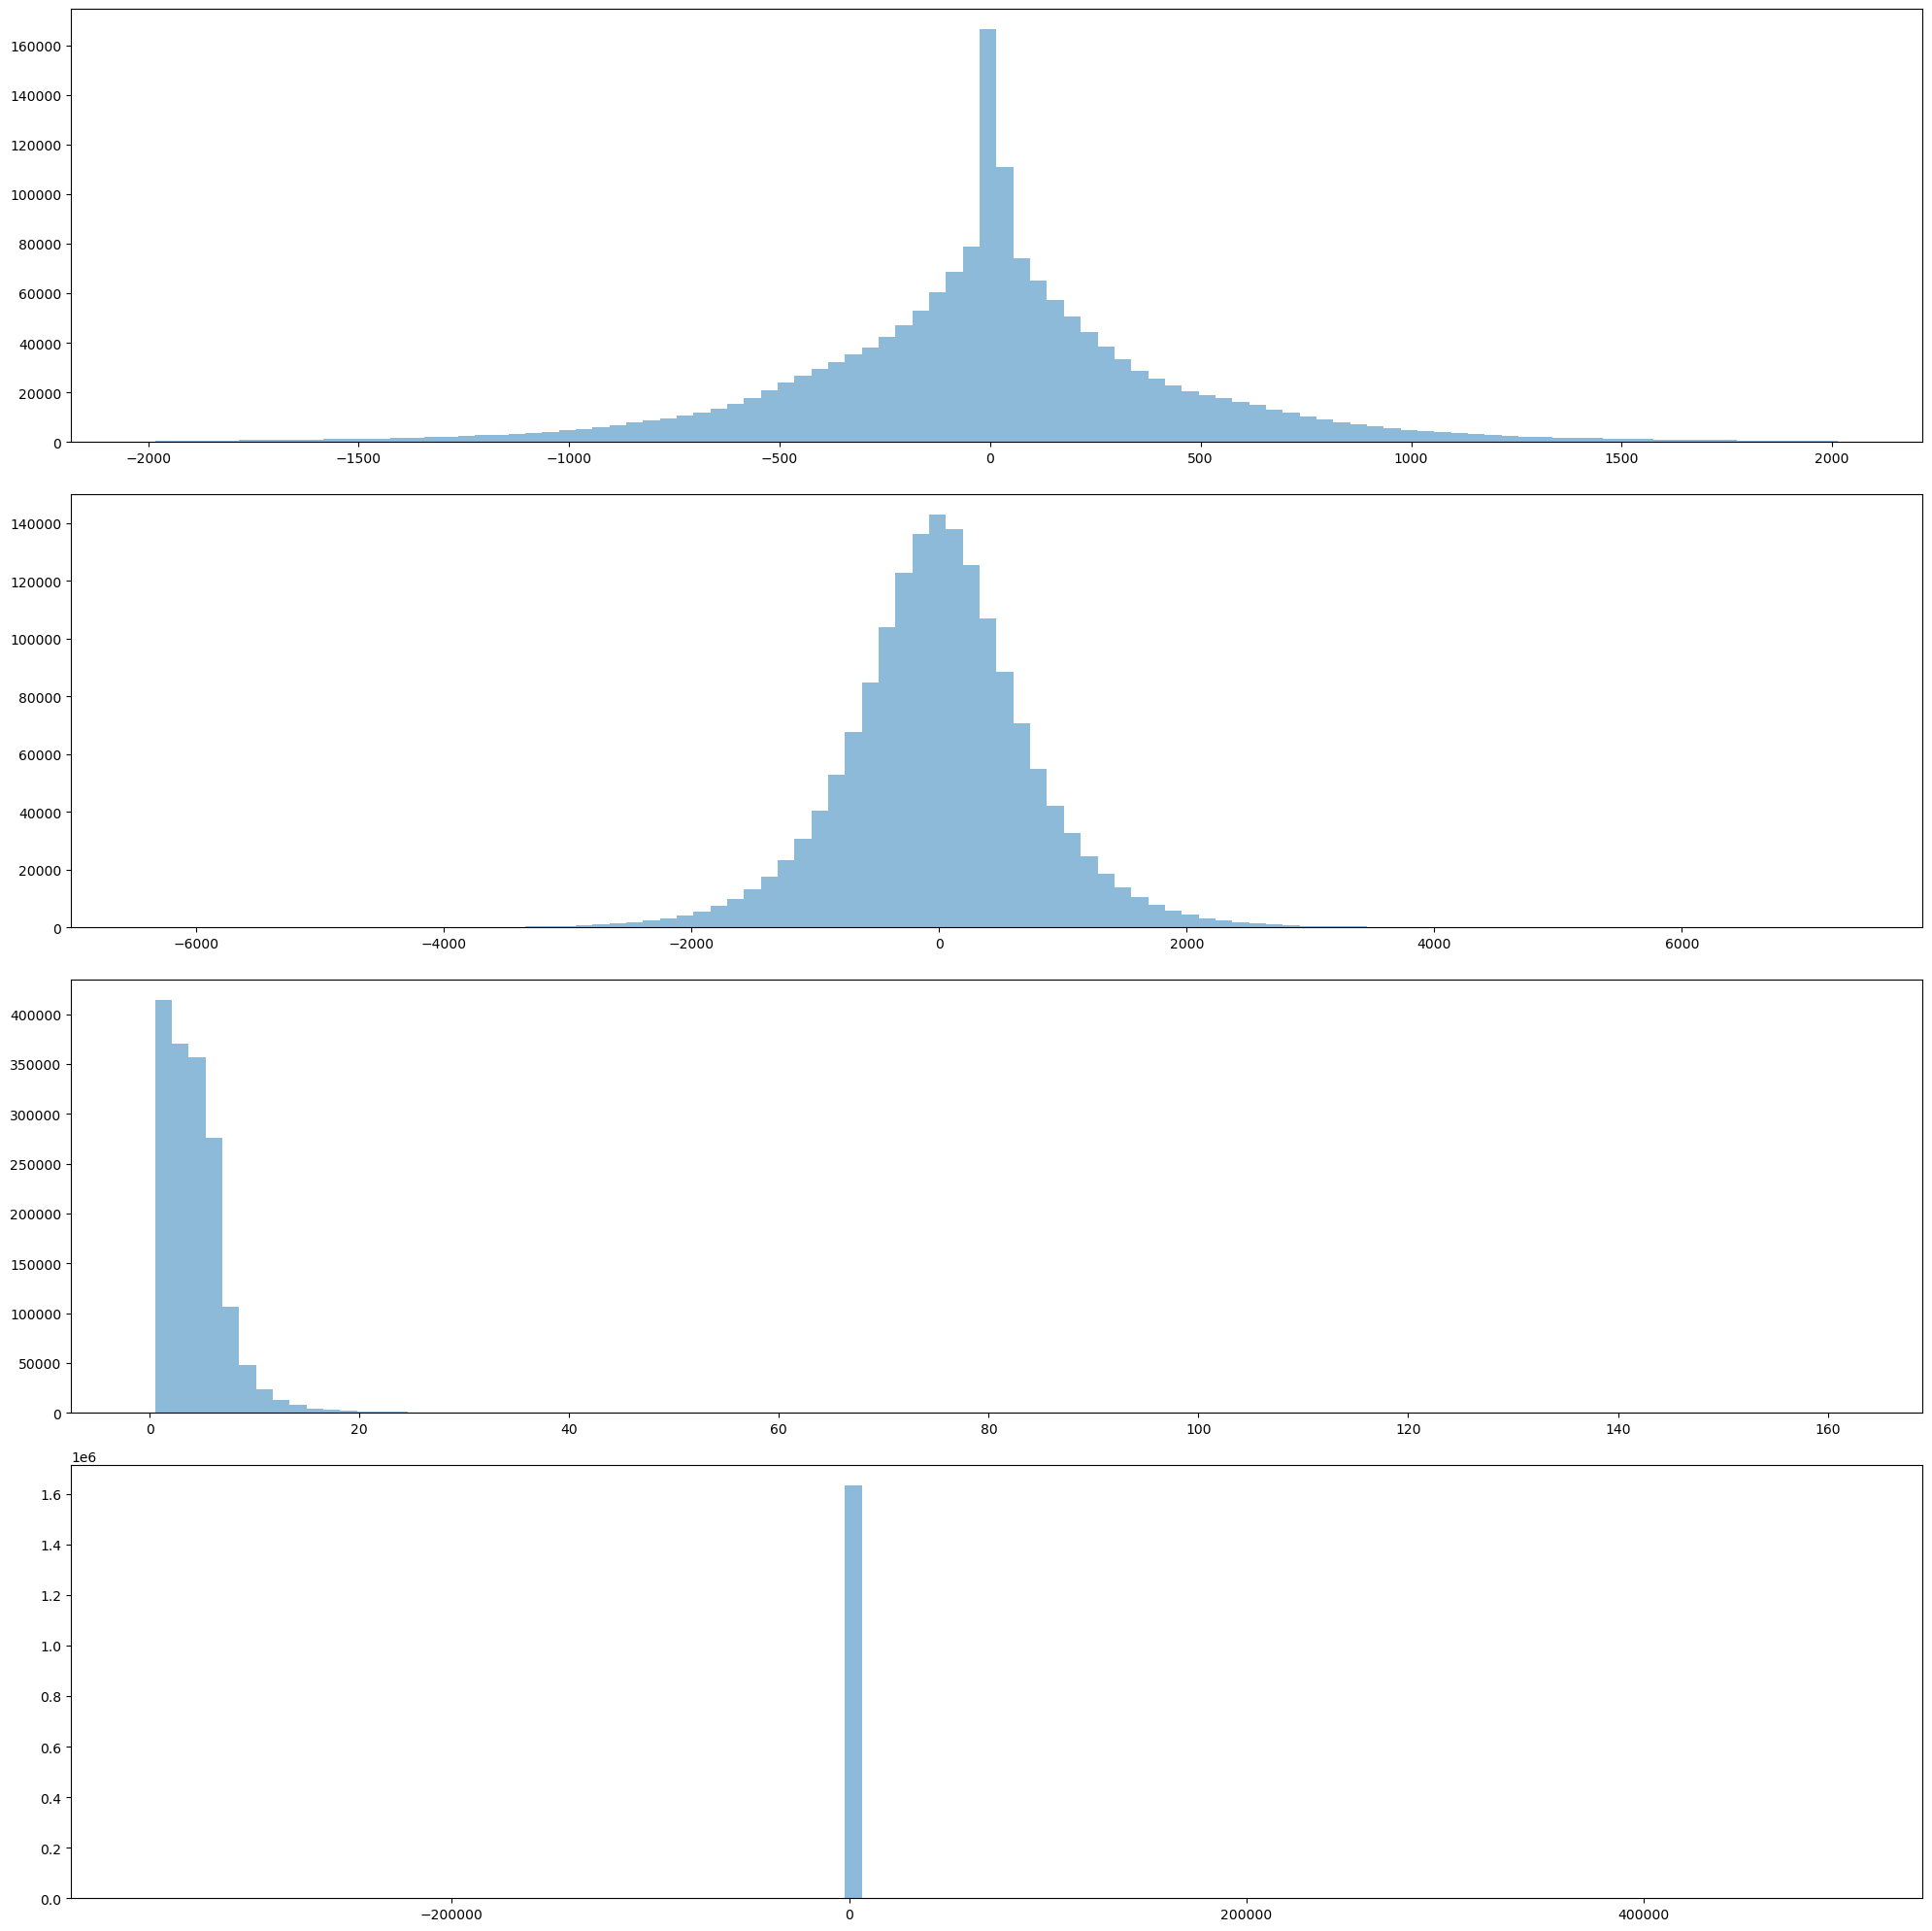

In [9]:
inferred_parallax = jft.mean_and_std(tuple(fwd(s) for s in samples))
inferred_dist = jft.mean_and_std(tuple(true_dist(s) for s in samples))

''' Plot Results'''
fig, axs = plt.subplots(4, 1, figsize=(20, 20))
axs[0].hist(1000./parallax*np.sin(b*deg2rad)+14.5, bins=100, alpha=0.5, label="Data")
axs[1].hist(inferred_dist[0], bins=100, alpha=0.5, label="Inferred")
axs[2].hist(parallax, bins=100, alpha=0.5, label="Data")
axs[3].hist(inferred_parallax[0], bins=100, alpha=0.5, label="Inferred")
fig.tight_layout()
plt.show()